In [1]:
print("Email Spam Classifier")

Email Spam Classifier


In [2]:
import pandas as pd
import sklearn

print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version: 2.3.3
Scikit-learn version: 1.7.2


In [3]:
import pandas as pd

data = {
    "message": [
        "Congratulations! You won a free prize!",
        "Claim your free reward now!",
        "You have won a lottery!",
        "Get a free iPhone today!",
        "Win cash by entering this competition!",
        "Urgent! You have won a cash prize!",
        "Click now to claim your reward!",
        "You have been selected for a free gift!",
        "Free vacation waiting for you!",
        "Congratulations! You are a lucky winner!",
        
        "Can you send me the assignment?",
        "Let's meet tomorrow.",
        "Please send me the lecture notes.",
        "Are you coming to class today?",
        "I will call you later.",
        "The meeting is at 3 PM.",
        "Please submit your project tomorrow.",
        "Can you help me with this task?",
        "Thanks for your help.",
        "See you tomorrow."
    ],
    
    "label": [
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham"
    ]
}

df = pd.DataFrame(data)

print(df)

                                     message label
0     Congratulations! You won a free prize!  spam
1                Claim your free reward now!  spam
2                    You have won a lottery!  spam
3                   Get a free iPhone today!  spam
4     Win cash by entering this competition!  spam
5         Urgent! You have won a cash prize!  spam
6            Click now to claim your reward!  spam
7    You have been selected for a free gift!  spam
8             Free vacation waiting for you!  spam
9   Congratulations! You are a lucky winner!  spam
10           Can you send me the assignment?   ham
11                      Let's meet tomorrow.   ham
12         Please send me the lecture notes.   ham
13            Are you coming to class today?   ham
14                    I will call you later.   ham
15                   The meeting is at 3 PM.   ham
16      Please submit your project tomorrow.   ham
17           Can you help me with this task?   ham
18                     Thanks f

In [4]:
X = df["message"]
y = df["label"]

print("Messages:")
print(X)

print("\nLabels:")
print(y)

Messages:
0       Congratulations! You won a free prize!
1                  Claim your free reward now!
2                      You have won a lottery!
3                     Get a free iPhone today!
4       Win cash by entering this competition!
5           Urgent! You have won a cash prize!
6              Click now to claim your reward!
7      You have been selected for a free gift!
8               Free vacation waiting for you!
9     Congratulations! You are a lucky winner!
10             Can you send me the assignment?
11                        Let's meet tomorrow.
12           Please send me the lecture notes.
13              Are you coming to class today?
14                      I will call you later.
15                     The meeting is at 3 PM.
16        Please submit your project tomorrow.
17             Can you help me with this task?
18                       Thanks for your help.
19                           See you tomorrow.
Name: message, dtype: object

Labels:
0     spam
1

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model trained successfully!")
print("Accuracy:", accuracy)

Model trained successfully!
Accuracy: 0.6


In [6]:
message = input("Enter an email/message: ")

prediction = model.predict([message])[0]

if prediction == "spam":
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

Enter an email/message:  Apply it now


Prediction: SPAM


In [7]:
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

urllib.request.urlretrieve(url, "spam_dataset.tsv")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [8]:
import pandas as pd

df = pd.read_csv(
    "spam_dataset.tsv",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset shape:", df.shape)
print()
print(df.head())

Dataset shape: (5572, 2)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [9]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model trained successfully!")
print("Accuracy:", accuracy)

Model trained successfully!
Accuracy: 0.9605381165919282


In [12]:
message = input("Enter a message: ")

prediction = model.predict([message])[0]

if prediction == "spam":
    print("🚨 Prediction: SPAM")
else:
    print("✅ Prediction: NOT SPAM")
    

Enter a message:  Congratulations! You have won a free iPhone. Click now to claim your prize!


🚨 Prediction: SPAM


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



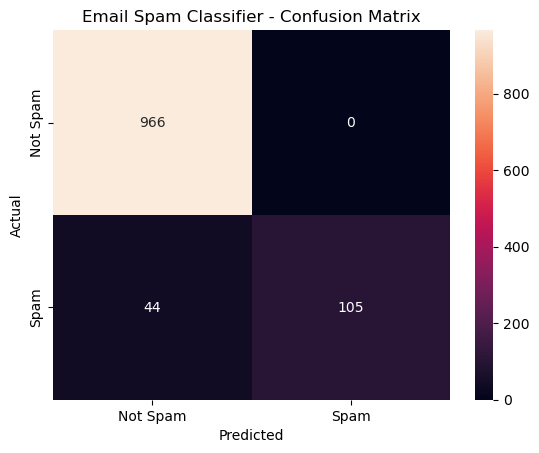

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Spam", "Spam"],
    yticklabels=["Not Spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Email Spam Classifier - Confusion Matrix")
plt.show()